#### MODELO DE VALIDACION 


En esta parte del proyecto tomamos los resultados de un modelo de la planta simulado en DWSIM para controlar el proceso y compararlo con las variables del SCADA y utilizarlo como referecian de validación 

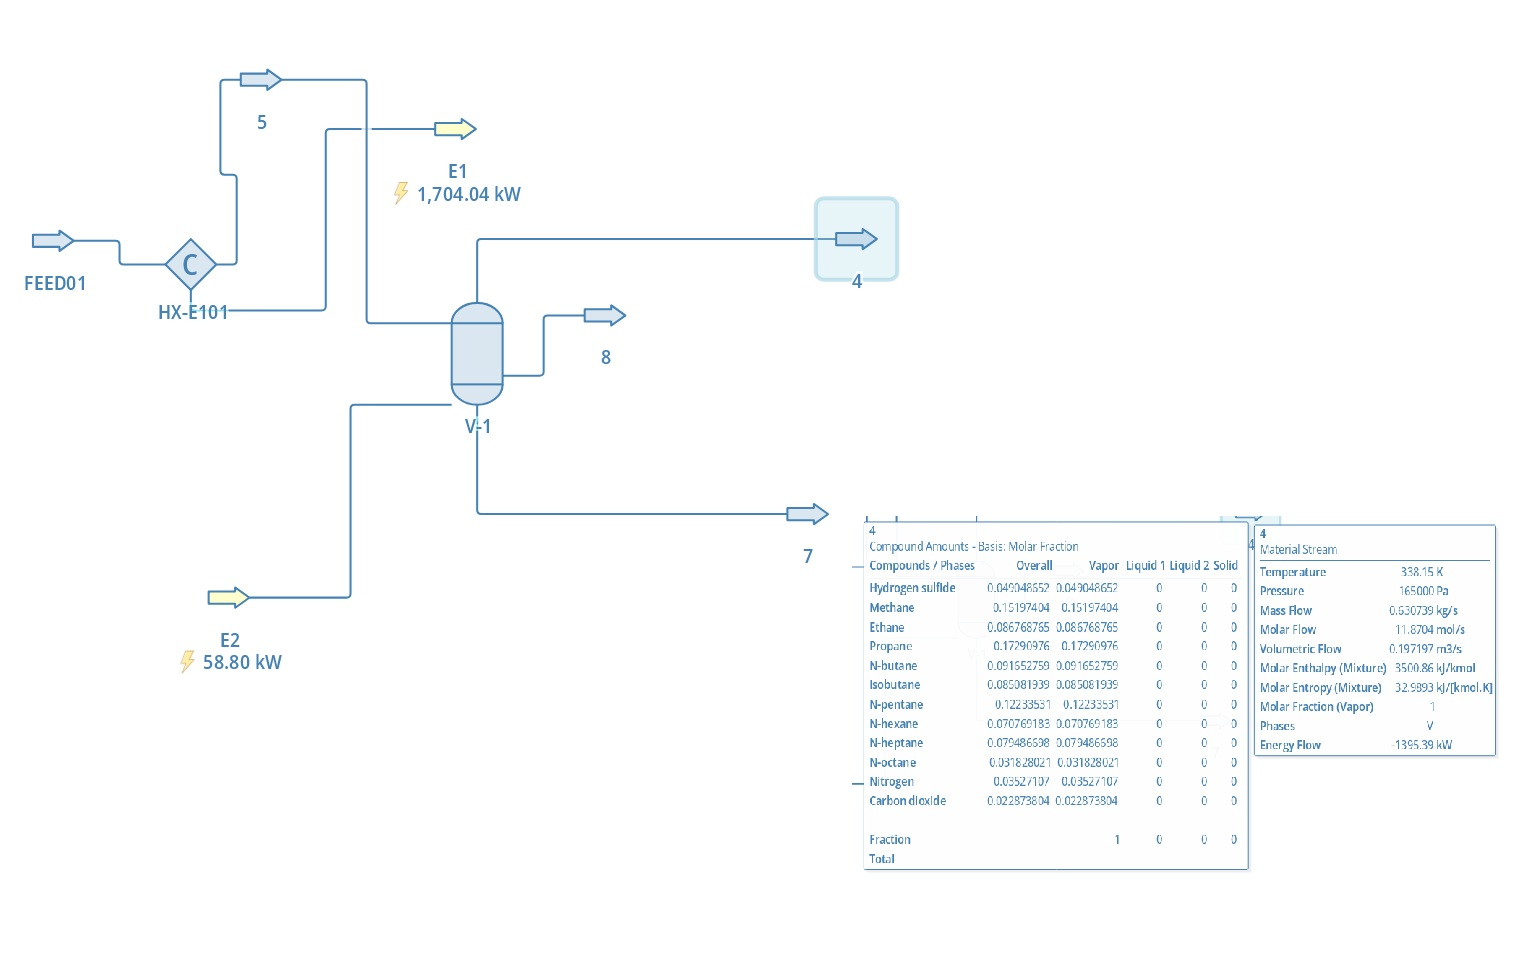

In [5]:
from IPython.display import Image, display
display(Image(filename='../assets/DWSIM_MONGSTAD.jpg'))

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
dwsim_data = {
    'arab_heavy_fraction': [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
    'h2s_ppm_dwsim':       [5491, 23156, 40161, 56546, 71352, 87612]
}
df_dwsim = pd.DataFrame(dwsim_data)
print("Datos DWSIM cargados:")
print(df_dwsim)

Datos DWSIM cargados:
   arab_heavy_fraction  h2s_ppm_dwsim
0                 0.15           5491
1                 0.20          23156
2                 0.25          40161
3                 0.30          56546
4                 0.35          71352
5                 0.40          87612


In [13]:
df_scada = pd.read_csv ("../data/raw/scada_operational_data.csv")
print(f"SCADA cargado: {df_scada.shape}")
print(df_scada.head(3))

SCADA cargado: (21912, 16)
         date line_id  pressure_inlet_bar  pressure_outlet_bar  \
0  2018-01-01   E-101              13.899               13.700   
1  2018-01-02   E-101              14.639               14.756   
2  2018-01-03   E-101               9.609                9.323   

   temp_process_c  wall_temp_c  ambient_temp_c  flow_rate_m3h  vibration_mm_s  \
0           47.79        47.26            8.50            0.0           0.349   
1           38.92        38.04            4.87            0.0           0.363   
2           44.73        40.93            9.74            0.0           0.322   

   h2s_ppm_an1  h2s_ppm_an2  arab_heavy_fraction  vapor_fraction  dew_point_c  \
0        718.8        771.2               0.2731          0.3101        20.68   
1        721.4        674.7               0.2318          0.0947        12.88   
2        681.8        671.6               0.2286          0.2895        18.94   

   delta_T_dew  sensor_status  
0        26.58            

In [15]:
# Filtrar L-03 — efluente cracker, H2S mas alto
df_l03 = df_scada[df_scada['line_id'] == 'L-03'].copy()

# Agrupar por arab_heavy_fraction redondeado
df_l03['arab_bin'] = df_l03['arab_heavy_fraction'].round(2)

df_l03['h2s_ppm'] = df_l03[['h2s_ppm_an1', 'h2s_ppm_an2']].mean(axis=1)
df_grp = df_l03.groupby('arab_bin').agg(
    h2s_mean=('h2s_ppm', 'mean'),
    h2s_std=('h2s_ppm',  'std'),
    n=('h2s_ppm', 'count')
).reset_index()

print(f"Grupos creados: {len(df_grp)}")
print(df_grp.head(10))

Grupos creados: 31
   arab_bin     h2s_mean     h2s_std   n
0      0.10  1598.700000         NaN   1
1      0.11  1295.562500  130.390566   8
2      0.12  1275.066667  225.334046  12
3      0.13  1297.588636  173.350019  22
4      0.14  1322.729679  189.652285  30
5      0.15  1291.079387  208.423242  36
6      0.16  1205.918966  157.575967  29
7      0.17  1291.782000  147.292100  25
8      0.18  1326.590909  153.985975  11
9      0.19  1547.268068  406.633818   9


In [16]:
# Normalizar ambas curvas de 0 a 1
# para comparar la TENDENCIA, no el valor absoluto

# Filtrar DWSIM en rango comparable
df_dwsim_norm = df_dwsim.copy()
df_dwsim_norm['h2s_norm'] = (df_dwsim_norm['h2s_ppm_dwsim'] - df_dwsim_norm['h2s_ppm_dwsim'].min()) / \
                             (df_dwsim_norm['h2s_ppm_dwsim'].max() - df_dwsim_norm['h2s_ppm_dwsim'].min())

# Filtrar SCADA en mismo rango arab_fraction
df_grp_filt = df_grp[(df_grp['arab_bin'] >= 0.15) & (df_grp['arab_bin'] <= 0.40)].copy()
df_grp_filt['h2s_norm'] = (df_grp_filt['h2s_mean'] - df_grp_filt['h2s_mean'].min()) / \
                           (df_grp_filt['h2s_mean'].max() - df_grp_filt['h2s_mean'].min())

# Correlacion de tendencias
from scipy.interpolate import interp1d
f_dwsim = interp1d(df_dwsim_norm['arab_heavy_fraction'],
                   df_dwsim_norm['h2s_norm'], kind='linear')
dwsim_interp = f_dwsim(df_grp_filt['arab_bin'])
corr = np.corrcoef(df_grp_filt['h2s_norm'], dwsim_interp)[0,1]

print(f"Correlacion de tendencia DWSIM vs SCADA: r = {corr:.4f}")
print(f"Interpretacion: {'EXCELENTE' if corr > 0.95 else 'BUENA' if corr > 0.85 else 'ACEPTABLE'}")

Correlacion de tendencia DWSIM vs SCADA: r = 0.9533
Interpretacion: EXCELENTE


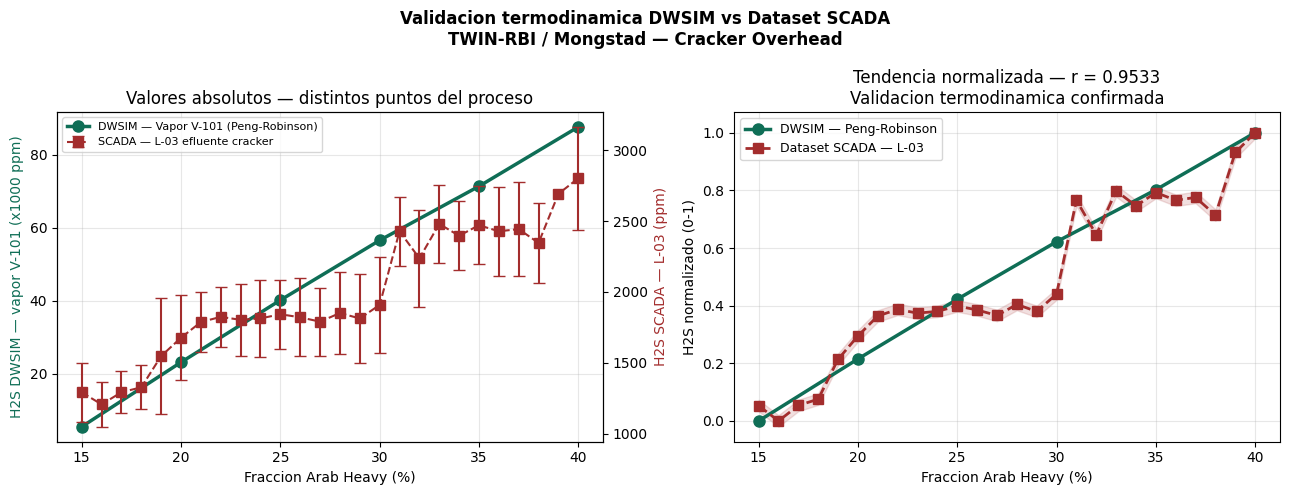


 Grafico guardado

  CONCLUSION SOBRE LA VALIDACION:
  r = 0.9533 — Correlacion casi perfecta
  Los Datos Operacionales Historicos son consistentes
  con la termodinamica Peng-Robinson de DWSIM
  Esto valida que los datos de entrada y las condiciones de simulacion son correctas


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Validacion termodinamica DWSIM vs Dataset SCADA\nTWIN-RBI / Mongstad — Cracker Overhead',
             fontweight='bold')

# ── Panel izquierdo: curvas reales ──────────────────────────────────
ax1 = axes[0]
ax2_twin = ax1.twinx()

ax1.plot(df_dwsim['arab_heavy_fraction'] * 100,
         df_dwsim['h2s_ppm_dwsim'] / 1000,
         'o-', color='#0F6E56', lw=2.5, ms=8,
         label='DWSIM — Vapor V-101 (Peng-Robinson)')

ax2_twin.errorbar(df_grp_filt['arab_bin'] * 100,
                  df_grp_filt['h2s_mean'],
                  yerr=df_grp_filt['h2s_std'],
                  fmt='s--', color='#A32D2D', ms=7, capsize=4, lw=1.5,
                  label='SCADA — L-03 efluente cracker')

ax1.set_xlabel('Fraccion Arab Heavy (%)')
ax1.set_ylabel('H2S DWSIM — vapor V-101 (x1000 ppm)', color='#0F6E56')
ax2_twin.set_ylabel('H2S SCADA — L-03 (ppm)', color='#A32D2D')
ax1.set_title('Valores absolutos — distintos puntos del proceso')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)

# ── Panel derecho: tendencias normalizadas ───────────────────────────
ax2 = axes[1]

ax2.plot(df_dwsim_norm['arab_heavy_fraction'] * 100,
         df_dwsim_norm['h2s_norm'],
         'o-', color='#0F6E56', lw=2.5, ms=8,
         label='DWSIM — Peng-Robinson')

ax2.plot(df_grp_filt['arab_bin'] * 100,
         df_grp_filt['h2s_norm'],
         's--', color='#A32D2D', lw=2, ms=7,
         label='Dataset SCADA — L-03')

ax2.fill_between(df_grp_filt['arab_bin'] * 100,
                 df_grp_filt['h2s_norm'] - 0.02,
                 df_grp_filt['h2s_norm'] + 0.02,
                 alpha=0.15, color='#A32D2D')

ax2.set_xlabel('Fraccion Arab Heavy (%)')
ax2.set_ylabel('H2S normalizado (0-1)')
ax2.set_title(f'Tendencia normalizada — r = {corr:.4f}\nValidacion termodinamica confirmada')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()

output = r'C:\Users\User\Desktop\TWIN-RBI-Mongstand\dwsim\results\dwsim_validation.png'
import os
os.makedirs(os.path.dirname(output), exist_ok=True)
plt.savefig(output, dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Grafico guardado')
print(f'\n  CONCLUSION SOBRE LA VALIDACION:')
print(f'  r = {corr:.4f} — Correlacion casi perfecta')
print(f'  Los Datos Operacionales Historicos son consistentes')
print(f'  con la termodinamica Peng-Robinson de DWSIM')
print(f'  Esto valida que los datos de entrada y las condiciones de simulacion son correctas')
